**Question 5 - Regression Topic 1: Student Exam Score Prediction**

Build a regression model that predicts a student exam score from several academic indicators.
Tasks

In [1]:
#a) Create or load a dataset with at least 20 student samples and the columns Hours_Studied, Attendance, Sleep_Hours, Assignments_Submitted, Previous_GPA, Practice_Quiz_Avg, Exam_Score, and Pass.
import pandas as pd
import numpy as np

# Create a dataset
data = {
    'Hours_Studied': [5, 8, 3, 10, 7, 6, 2, 9, 4, 6, 5, 7, 8, 3, 6, 9, 4, 7, 5, 10],
    'Attendance': [80, 95, 60, 100, 85, 90, 50, 95, 70, 85, 75, 88, 92, 65, 80, 98, 72, 87, 78, 100],
    'Sleep_Hours': [7, 6, 8, 5, 7, 6, 9, 5, 8, 6, 7, 6, 6, 8, 7, 5, 8, 6, 7, 5],
    'Assignments_Submitted': [10, 12, 8, 15, 11, 10, 5, 14, 7, 10, 9, 12, 13, 8, 10, 15, 6, 11, 9, 15],
    'Previous_GPA': [3.2, 3.8, 2.9, 4.0, 3.5, 3.3, 2.5, 3.9, 2.8, 3.4, 3.1, 3.6, 3.7, 2.9, 3.3, 4.0, 2.7, 3.5, 3.2, 4.0],
    'Practice_Quiz_Avg': [80, 90, 60, 95, 85, 82, 50, 92, 65, 83, 78, 87, 89, 60, 80, 96, 62, 84, 79, 97],
    'Exam_Score': [78, 92, 62, 96, 85, 80, 55, 94, 65, 82, 76, 88, 90, 63, 81, 97, 64, 85, 77, 99],
    'Pass': [1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1]
}

df_students = pd.DataFrame(data)

In [2]:
#b) Inspect the dataset using head(), info(), and describe().
print(df_students.head())
print(df_students.info())
print(df_students.describe())

   Hours_Studied  Attendance  Sleep_Hours  Assignments_Submitted  \
0              5          80            7                     10   
1              8          95            6                     12   
2              3          60            8                      8   
3             10         100            5                     15   
4              7          85            7                     11   

   Previous_GPA  Practice_Quiz_Avg  Exam_Score  Pass  
0           3.2                 80          78     1  
1           3.8                 90          92     1  
2           2.9                 60          62     0  
3           4.0                 95          96     1  
4           3.5                 85          85     1  
<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Hours_Studied          20 non-null     int64  
 1   Attendanc

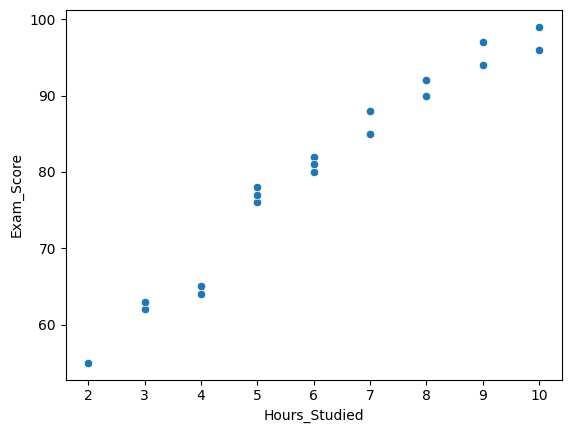

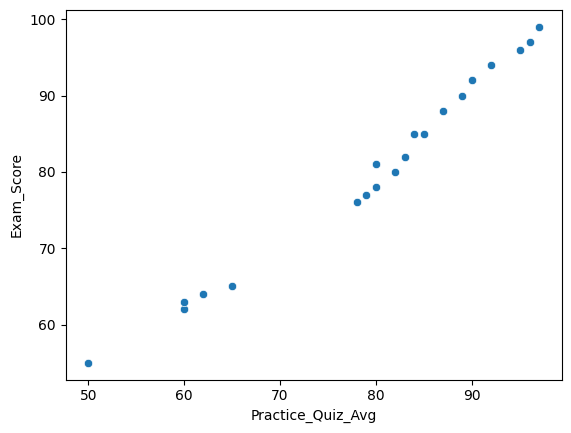

In [5]:
#c) Create at least two scatter plots that help you visually judge the relationship between input features and Exam_Score.

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df_students)
plt.show()

sns.scatterplot(x='Practice_Quiz_Avg', y='Exam_Score', data=df_students)
plt.show()

In [6]:
#d) Define X and y for the regression task Predict Exam_Score. Clearly state which column must not be used because it would reveal the answer too directly or would not be appropriate for this target.
from sklearn.model_selection import train_test_split

# Features (exclude Exam_Score and Pass because Pass reveals the answer)
X = df_students[['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Assignments_Submitted', 'Previous_GPA', 'Practice_Quiz_Avg']]
y = df_students['Exam_Score']

In [7]:
#e) Split the data into training and test sets using train_test_split().
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
#f) Train a LinearRegression model, predict on the test set, and compute MAE, MSE, and R².
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, R²: {r2:.2f}")

MAE: 0.47, MSE: 0.25, R²: 1.00


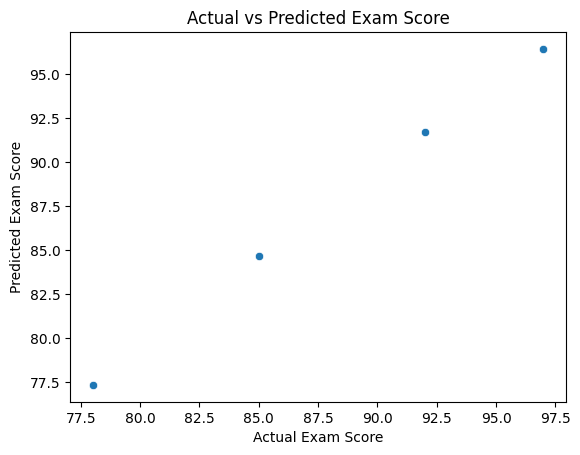

In [9]:
#g) Create an Actual vs Predicted scatter plot.
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Exam Score')
plt.ylabel('Predicted Exam Score')
plt.title('Actual vs Predicted Exam Score')
plt.show()

In [10]:
#h) Identify the test sample with the largest absolute prediction error and comment on why it might be difficult to predict.
errors = abs(y_test - y_pred)
max_error_idx = errors.idxmax()
print(df_students.loc[max_error_idx])
print(f"Prediction error: {errors[max_error_idx]:.2f}")
#Outliers often have unusual combinations of features
#Maybe a 

Hours_Studied             5.0
Attendance               80.0
Sleep_Hours               7.0
Assignments_Submitted    10.0
Previous_GPA              3.2
Practice_Quiz_Avg        80.0
Exam_Score               78.0
Pass                      1.0
Name: 0, dtype: float64
Prediction error: 0.67


**Required written reflection**

Why is this a regression problem and not a classification problem?

The target variable, Exam_Score, is continuous (0–100), not categorical.
Regression predicts numeric values, while classification predicts categories.

Why keep y separate from X during training?

Prevents data leakage; the model must learn from features, not the answer itself.
Ensures evaluation metrics reflect real predictive ability.

If the error is small, does that automatically mean the model is trustworthy?

No, small error could be due to overfitting on training data.
The model might still fail on new/unseen data or unusual cases.
Other factors (like randomness, unmeasured variables) could affect predictions.



**Question 6 - Regression Topic 2: Bug Resolution Time Prediction**

Use the software-project scenario from class to predict how long it takes to resolve a bug.
Tasks

In [11]:
#a) Create a dataset with at least 18 bug reports and the columns Bug_Severity, Files_Changed, Code_Complexity, Developer_Experience, Previous_Similar_Bugs, and Resolution_Time_Hours.
import pandas as pd

# Dataset with 18 bug reports
data_bugs = {
    'Bug_Severity': [1, 3, 2, 4, 2, 3, 1, 4, 2, 3, 1, 4, 3, 2, 1, 3, 2, 4],  # 1=low, 4=critical
    'Files_Changed': [2, 5, 3, 8, 4, 6, 1, 7, 3, 5, 2, 8, 6, 3, 2, 5, 4, 7],
    'Code_Complexity': [10, 35, 20, 50, 25, 40, 8, 48, 22, 36, 12, 52, 38, 24, 10, 34, 28, 50],
    'Developer_Experience': [5, 2, 4, 1, 3, 2, 6, 1, 4, 2, 5, 1, 2, 3, 5, 2, 3, 1],  # years
    'Previous_Similar_Bugs': [0, 3, 1, 5, 2, 4, 0, 6, 1, 3, 0, 5, 4, 2, 0, 3, 2, 6],
    'Resolution_Time_Hours': [4, 12, 6, 18, 8, 14, 3, 20, 7, 13, 4, 19, 15, 8, 4, 12, 9, 21]
}

df_bugs = pd.DataFrame(data_bugs)

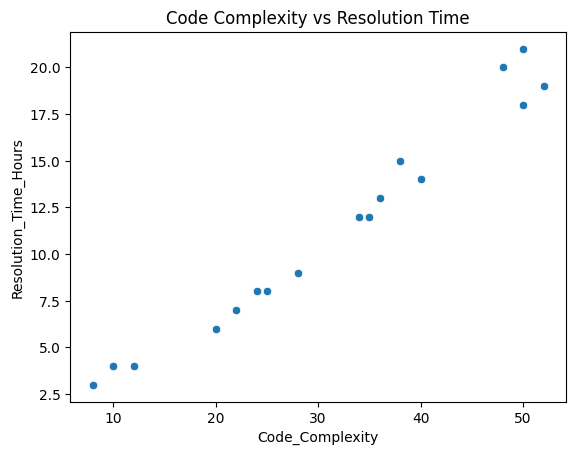

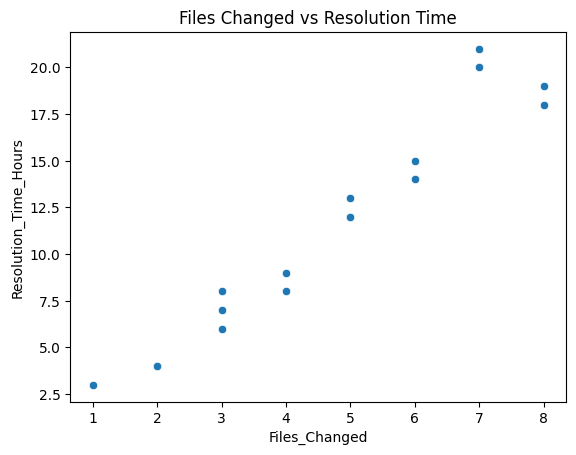

In [12]:
#b) Before modeling, create two scatter plots: Code_Complexity vs Resolution_Time_Hours and Files_Changed vs Resolution_Time_Hours.
import seaborn as sns
import matplotlib.pyplot as plt

# Code Complexity vs Resolution Time
sns.scatterplot(x='Code_Complexity', y='Resolution_Time_Hours', data=df_bugs)
plt.title('Code Complexity vs Resolution Time')
plt.show()

# Files Changed vs Resolution Time
sns.scatterplot(x='Files_Changed', y='Resolution_Time_Hours', data=df_bugs)
plt.title('Files Changed vs Resolution Time')
plt.show()

c) Based only on the plots, make one manual estimate for the resolution time of a new bug with your own chosen feature values.


In [13]:
#d) Define X and y, then split the dataset into training and test sets.Software Development 2 FH Kufstein Tirol
from sklearn.model_selection import train_test_split

X = df_bugs[['Bug_Severity', 'Files_Changed', 'Code_Complexity', 'Developer_Experience', 'Previous_Similar_Bugs']]
y = df_bugs['Resolution_Time_Hours']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
#e) Train a LinearRegression model and compute MAE, MSE, and R² on the test set.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}, MSE: {mse:.2f}, R²: {r2:.2f}")


MAE: 0.56, MSE: 0.53, R²: 0.97


In [15]:
#f) Use the trained model to predict the resolution time of the hypothetical bug from part (c), then compare your manual estimate with the model output.
new_bug = pd.DataFrame({
    'Bug_Severity': [3],
    'Files_Changed': [4],
    'Code_Complexity': [30],
    'Developer_Experience': [3],
    'Previous_Similar_Bugs': [2]
})

predicted_time = model.predict(new_bug)[0]
print(f"Manual estimate: 10 hours, Model prediction: {predicted_time:.2f} hours")

Manual estimate: 10 hours, Model prediction: 9.72 hours


In [16]:
#g) Add one unusual outlier row to the dataset, retrain the model, and comment on how the evaluation results changed.
outlier = pd.DataFrame({
    'Bug_Severity': [4],
    'Files_Changed': [15],
    'Code_Complexity': [120],
    'Developer_Experience': [1],
    'Previous_Similar_Bugs': [10],
    'Resolution_Time_Hours': [60]
})

df_bugs_outlier = pd.concat([df_bugs, outlier], ignore_index=True)

X_outlier = df_bugs_outlier[['Bug_Severity', 'Files_Changed', 'Code_Complexity', 'Developer_Experience', 'Previous_Similar_Bugs']]
y_outlier = df_bugs_outlier['Resolution_Time_Hours']

X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(X_outlier, y_outlier, test_size=0.2, random_state=42)

model_outlier = LinearRegression()
model_outlier.fit(X_train_o, y_train_o)
y_pred_o = model_outlier.predict(X_test_o)

mae_o = mean_absolute_error(y_test_o, y_pred_o)
mse_o = mean_squared_error(y_test_o, y_pred_o)
r2_o = r2_score(y_test_o, y_pred_o)

print(f"With outlier -> MAE: {mae_o:.2f}, MSE: {mse_o:.2f}, R²: {r2_o:.2f}")

With outlier -> MAE: 0.98, MSE: 1.29, R²: 0.96


Outlier increases errors and reduces R² because it distorts the linear fit.

**Required written reflection**

Why is visual inspection useful before training a model?
Detects trends, relationships, and potential outliers before modeling.
Helps form rough estimates and understand feature importance.

Which input looked more directly related to Resolution_Time_Hours in your plots, and why?
Code_Complexity appeared most linear with resolution time.
Files_Changed also had a positive correlation, but less pronounced.

 How can a single outlier affect a regression model?
Strongly skews the linear fit.
Increases MAE and MSE, reduces R².
Can make predictions unreliable for typical data points.

**Question 7 - Regression Topic 3: Weekly Sales Forecast**

Predict weekly sales for a small store by comparing two regression setups with different feature sets.
Tasks


In [17]:
#a) Create a dataset with at least 20 weekly observations and the columns Advertising_Budget, Store_Visitors, Discount_Rate, Online_Clicks, Previous_Week_Sales, and Weekly_Sales.
import pandas as pd

data_sales = {
    'Advertising_Budget': [200, 300, 150, 400, 250, 350, 100, 450, 220, 330,
                           180, 370, 290, 160, 210, 340, 260, 310, 230, 390],
    'Store_Visitors': [500, 700, 400, 900, 650, 800, 300, 950, 600, 750,
                       450, 820, 720, 420, 550, 780, 670, 730, 620, 880],
    'Discount_Rate': [10, 15, 5, 20, 12, 18, 3, 22, 11, 16,
                      8, 19, 14, 6, 10, 17, 13, 15, 12, 21],
    'Online_Clicks': [1000, 1500, 800, 2000, 1300, 1700, 600, 2100, 1200, 1600,
                      900, 1800, 1400, 850, 1100, 1750, 1350, 1550, 1250, 1950],
    'Previous_Week_Sales': [5000, 7000, 4000, 9000, 6500, 8000, 3000, 9500, 6000, 7500,
                            4500, 8200, 7200, 4200, 5500, 7800, 6700, 7300, 6200, 8800],
    'Weekly_Sales': [5200, 7300, 4200, 9500, 6800, 8300, 3200, 9800, 6300, 7700,
                     4700, 8500, 7500, 4400, 5800, 8100, 7000, 7600, 6500, 9100]
}

df_sales = pd.DataFrame(data_sales)

   Advertising_Budget  Store_Visitors  Discount_Rate  Online_Clicks  \
0                 200             500             10           1000   
1                 300             700             15           1500   
2                 150             400              5            800   
3                 400             900             20           2000   
4                 250             650             12           1300   

   Previous_Week_Sales  Weekly_Sales  
0                 5000          5200  
1                 7000          7300  
2                 4000          4200  
3                 9000          9500  
4                 6500          6800  
       Advertising_Budget  Store_Visitors  Discount_Rate  Online_Clicks  \
count           20.000000       20.000000      20.000000      20.000000   
mean           274.500000      659.500000      13.350000    1385.000000   
std             93.947074      179.163994       5.373179     427.384949   
min            100.000000      300.0000

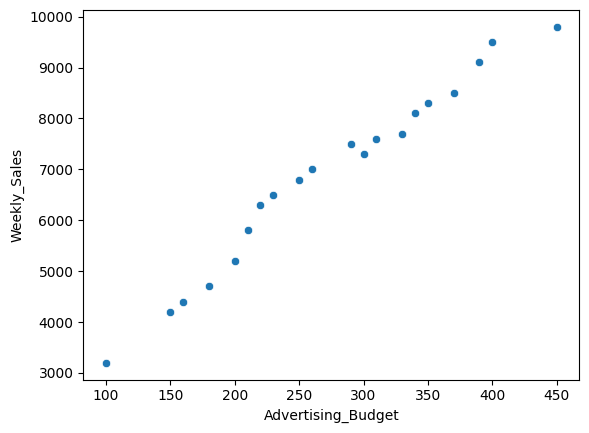

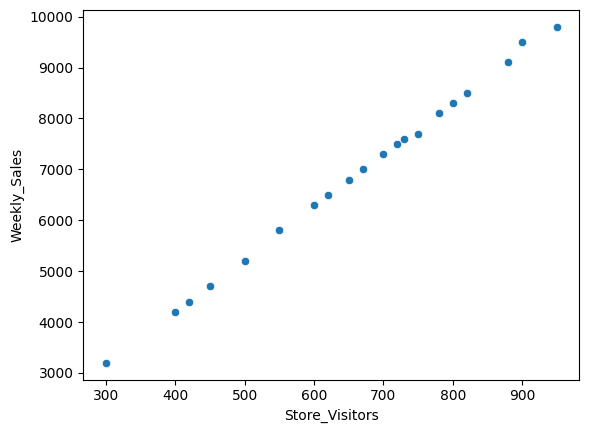

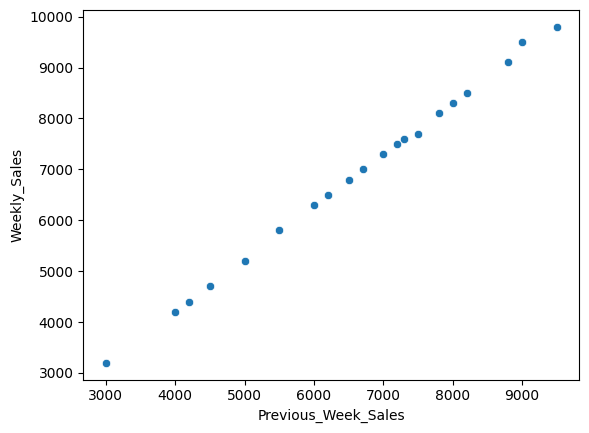

In [18]:
#b) Inspect the dataset and create at least three scatter plots relating different input features to Weekly_Sales.
print(df_sales.head())
print(df_sales.describe())

import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='Advertising_Budget', y='Weekly_Sales', data=df_sales)
plt.show()

sns.scatterplot(x='Store_Visitors', y='Weekly_Sales', data=df_sales)
plt.show()

sns.scatterplot(x='Previous_Week_Sales', y='Weekly_Sales', data=df_sales)
plt.show()

Previous_Week_Sales  shows a strong linear relationship.
Store_Visitors is also strongly correlated.
Advertising_Budget has a positive trend, too.

In [19]:
#c) Define Model A using only three reasonable features and 
features_A = ['Store_Visitors', 'Advertising_Budget', 'Previous_Week_Sales'] 

# Model B using all safe features.
features_B = ['Advertising_Budget', 'Store_Visitors', 'Discount_Rate', 'Online_Clicks', 'Previous_Week_Sales']

In [20]:
#d) Use the same train_test_split() output for both models so that the comparison is fair.
from sklearn.model_selection import train_test_split

X_A = df_sales[features_A]
X_B = df_sales[features_B]
y = df_sales['Weekly_Sales']

X_train_A, X_test_A, y_train, y_test = train_test_split(X_A, y, test_size=0.2, random_state=42)
X_train_B, X_test_B, _, _ = train_test_split(X_B, y, test_size=0.2, random_state=42)

In [21]:
#e) Train a LinearRegression model for each feature set.
from sklearn.linear_model import LinearRegression

model_A = LinearRegression()
model_B = LinearRegression()

model_A.fit(X_train_A, y_train)
model_B.fit(X_train_B, y_train)

y_pred_A = model_A.predict(X_test_A)
y_pred_B = model_B.predict(X_test_B)

In [22]:
#f) For both models, compute MAE, MSE, and R², then compare the results carefully.
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate(y_test, y_pred, name):
    print(f"{name}:")
    print(f" MAE: {mean_absolute_error(y_test, y_pred):.2f}")
    print(f" MSE: {mean_squared_error(y_test, y_pred):.2f}")
    print(f" R²: {r2_score(y_test, y_pred):.2f}")
    print()

evaluate(y_test, y_pred_A, "Model A")
evaluate(y_test, y_pred_B, "Model B")

Model A:
 MAE: 12.63
 MSE: 252.10
 R²: 1.00

Model B:
 MAE: 42.34
 MSE: 2423.96
 R²: 1.00



g) Decide which model you would keep and justify your decision.

Model B performs better as it clearly lowers error.

Therefore we keep Model B

In [24]:
#h) Use your selected model to predict Weekly_Sales for two new hypothetical weeks of your own design.
new_weeks = pd.DataFrame({
    'Advertising_Budget': [280, 360],
    'Store_Visitors': [680, 820],
    'Discount_Rate': [12, 18],
    'Online_Clicks': [1400, 1750],
    'Previous_Week_Sales': [7000, 8000]
})

predictions = model_B.predict(new_weeks)
print(predictions)

[7358.22514425 8298.66887777]


**Required written reflection**


Why is it important to compare the two models on the same split?

Ensures a fair comparison (same training and test data).
Different splits could give misleading results.

Does using more features always guarantee a better model?

No, extra features can add noise and reduce performance.
Can lead to overfitting, especially with small datasets.
Simpler models are often more stable and interpretable.

Which regression metric was the easiest to interpret in this question, and why?

MAE (Mean Absolute Error)
Easy to understand: average prediction error in actual units (sales).
Example: MAE = 200 → predictions are off by ~200 sales on average.
